In [1]:
from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

dataset = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    exclude_subjects=["01", "07", "09", "12"],
    tr=2.1,
    task="sleep",
    desc_add="clean-with-fd-clamped",
    # trim_trs=(1,1),
)




EOG data not full for 18, 1 (0/427). Skipping
EOG data not full for 18, 2 (0/427). Skipping
EOG data not full for 18, 3 (0/427). Skipping
EOG data not full for 18, 4 (0/427). Skipping
EOG data not full for 18, 5 (0/427). Skipping
EOG data not full for 16, 1 (282/427). Skipping
EOG data not full for 16, 2 (282/427). Skipping
EOG data not full for 16, 3 (293/427). Skipping
EOG data not full for 16, 4 (234/427). Skipping
EOG data not full for 16, 5 (237/427). Skipping
EOG data not full for 11, 5 (161/427). Skipping
EOG data not full for 23, 2 (0/427). Skipping
EOG data not full for 23, 3 (0/427). Skipping
EOG data not full for 15, 3 (151/427). Skipping


/Users/zach/.virtualenvs/sleepmreye/lib/python3.11/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



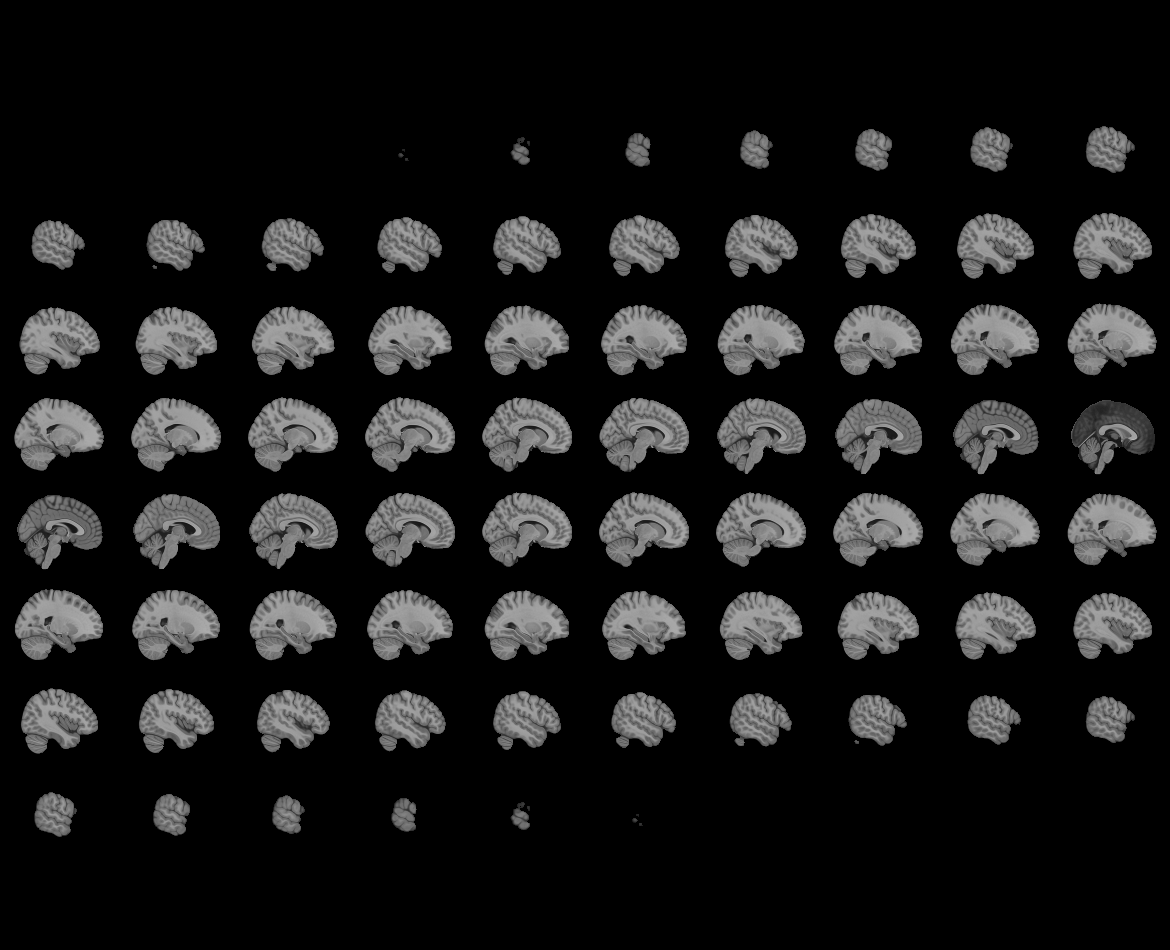
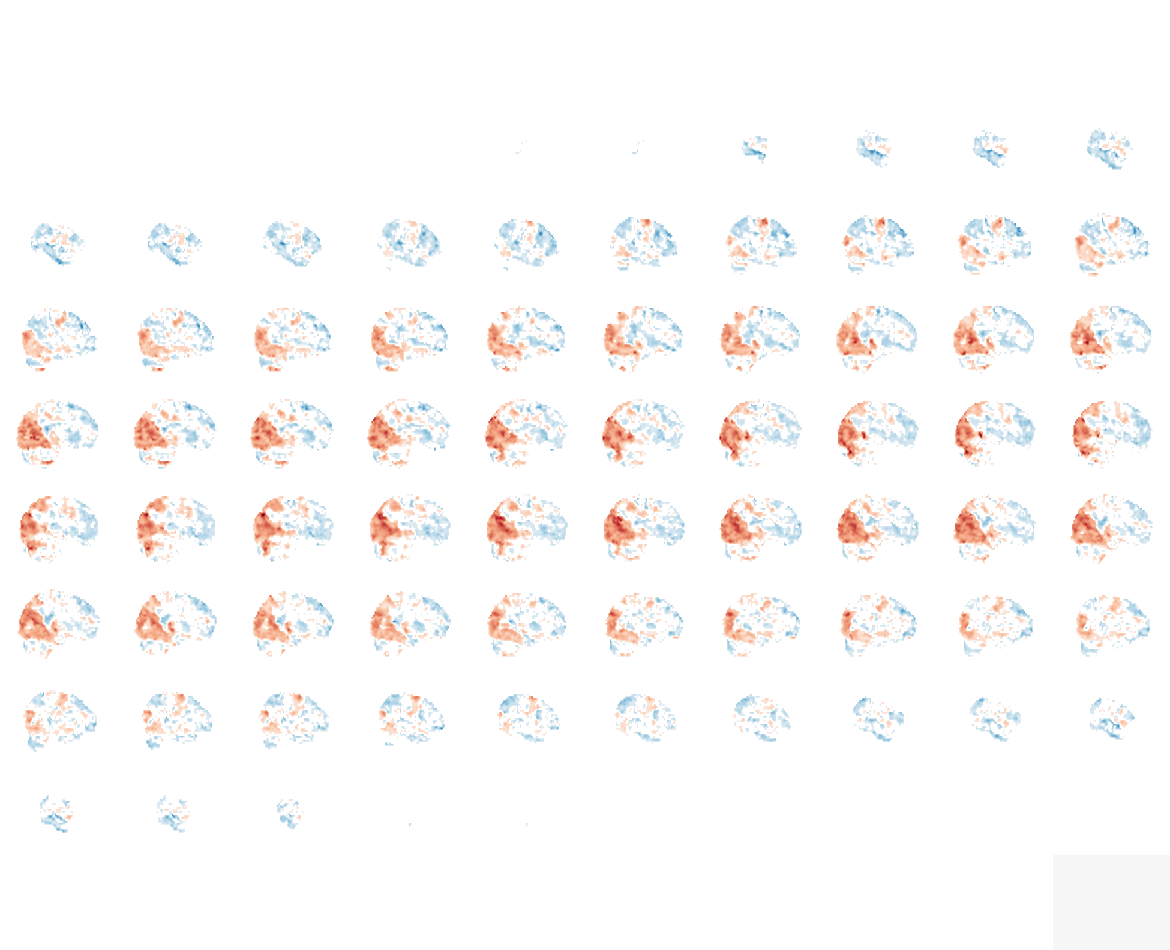

In [8]:
from nilearn import plotting 

plotting.view_img('/Users/zach/2025_RA/matthias/final images/tmaps/wake_tmap_group.nii.gz', threshold=1)

In [31]:

subject = "04"
run = 5
state = "2"
df = dataset.events

run_df = df[(df["subject"] == subject) & (df["run"] == run)]
state_mask = run_df[state].reset_index(drop=True).to_numpy()
state_mask.sum()


15

/Users/zach/.virtualenvs/sleepmreye/lib/python3.11/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_3819/1428535506.py:3: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  plotting.view_img('/Users/zach/2025_RA/matthias/final images/tmaps/mreyemove_tmap_group.nii.gz', threshold=2, )



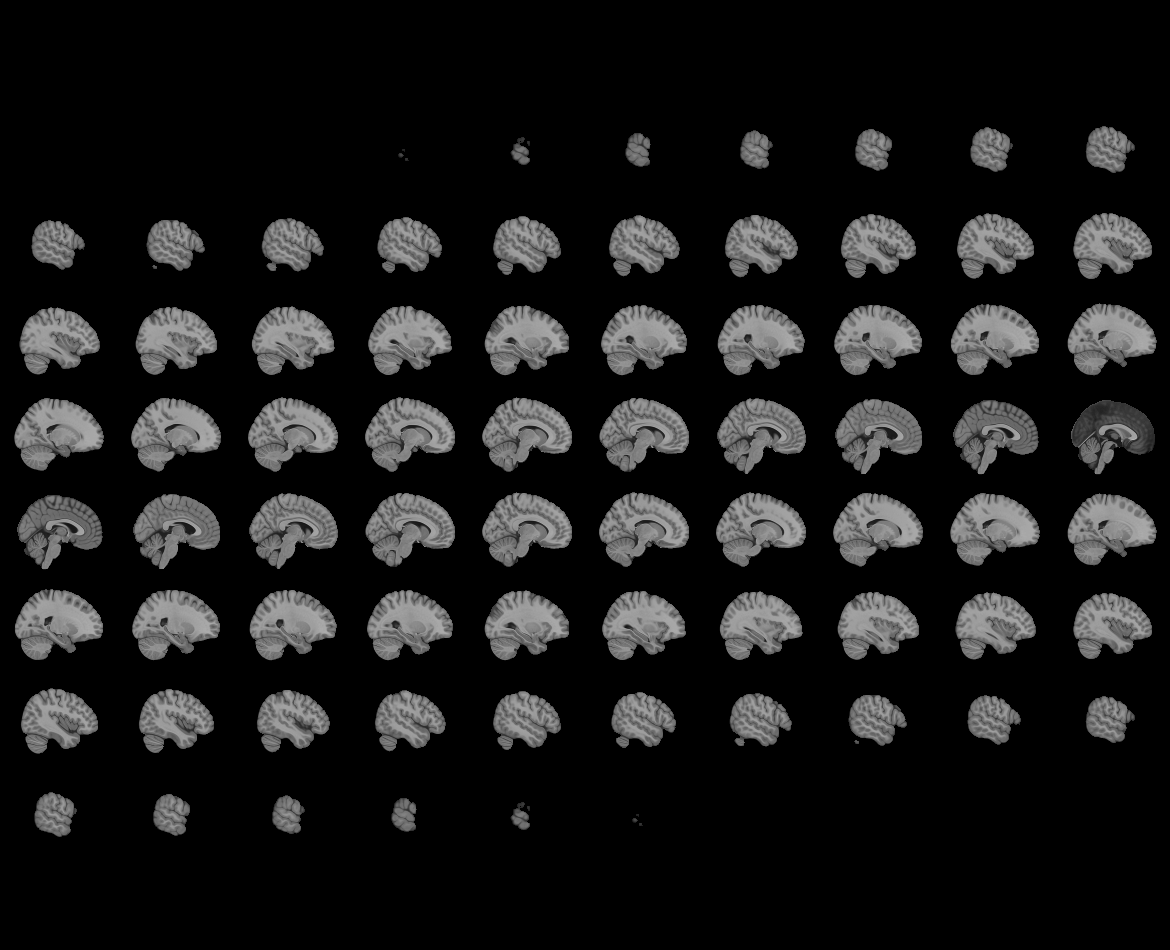
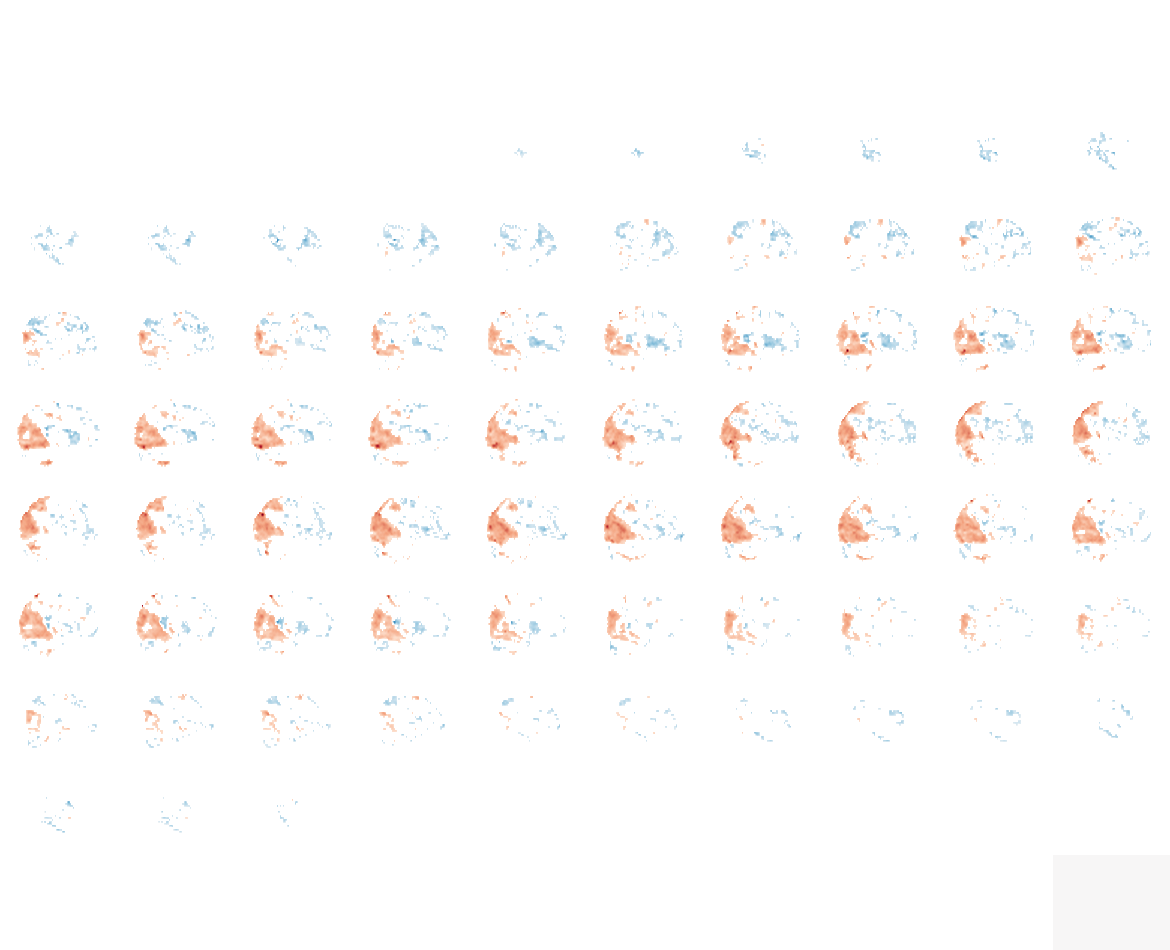

In [17]:
from nilearn import plotting

plotting.view_img('/Users/zach/2025_RA/matthias/final images/tmaps/mreyemove_tmap_group.nii.gz', threshold=2, )

  Skipping 15 run 3 (no EOG data)
  Skipping 16 run 1 (no EOG data)
  Skipping 16 run 2 (no EOG data)
  Skipping 16 run 3 (no EOG data)
  Skipping 16 run 4 (no EOG data)
  Skipping 16 run 5 (no EOG data)
  Skipping 18 run 1 (no EOG data)
  Skipping 18 run 2 (no EOG data)
  Skipping 18 run 3 (no EOG data)
  Skipping 18 run 4 (no EOG data)
  Skipping 18 run 5 (no EOG data)

Per-run correlations (146 runs):

Per-subject mean r (Fisher-averaged):
   subject  fisher_mean_r  n_runs
0       03          0.308       8
1       04          0.460       6
2       05          0.357       6
3       06          0.403       4
4       08          0.291       7
5       10          0.170       6
6       11          0.288       2
7       13          0.366       4
8       14          0.289       7
9       15          0.314       5
10      16          0.335       1
11      17          0.221       6
12      19          0.211       5
13      20          0.250       4
14      22          0.201       8
15      2

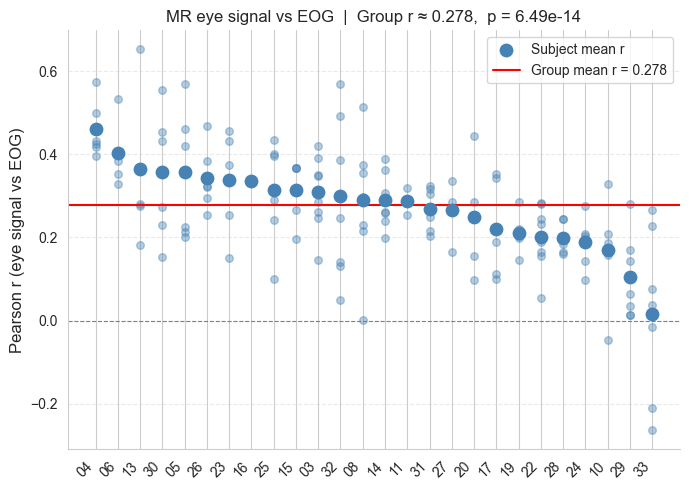

In [6]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# ── 1. Collect per-run correlations ──────────────────────────────────────────

records = []

for subject, run, run_df in dataset.iter_run_events():
    eye_signal = run_df["mreyemove"] # dataset.load_eye_move(subject, run, desc_add="clean-with-fd-clamped")

    eog_rows = run_df["eog"]
    if eog_rows.isna().any():
        print(f"  Skipping {subject} run {run} (no EOG data)")
        continue

    eog_signal = eog_rows.values.astype(float)

    if len(eye_signal) != len(eog_signal):
        print(f"  Skipping {subject} run {run} (length mismatch: eye={len(eye_signal)}, eog={len(eog_signal)})")
        continue

    r, _ = stats.pearsonr(eye_signal, eog_signal)  # per-run p-value not used; would be anticonservative
    if np.isnan(r):
        continue

    records.append(dict(
        subject=subject,
        run=run,
        r=r,
        n=len(eye_signal),
        mean_eye=np.mean(np.abs(eye_signal)),
        mean_eog=np.mean(np.abs(eog_signal)),
    ))

run_df = pd.DataFrame(records)
print(f"\nPer-run correlations ({len(run_df)} runs):")

# ── 2. Per-subject average r (Fisher z then back) ────────────────────────────

def fisher_mean(r_values):
    z = np.arctanh(np.clip(r_values, -0.9999, 0.9999))
    return np.tanh(np.mean(z))

subj_df = (
    run_df.groupby("subject")["r"]
    .agg(fisher_mean_r=lambda x: fisher_mean(x.values), n_runs="count")
    .reset_index()
)

print(f"\nPer-subject mean r (Fisher-averaged):")
print(subj_df.round(3))

# ── 3. Group-level summary ────────────────────────────────────────────────────
# t-test directly on Fisher-averaged per-subject r values (no second z-transform)

subj_r_vals = subj_df["fisher_mean_r"].values
group_r = np.tanh(np.mean(np.arctanh(np.clip(subj_r_vals, -0.9999, 0.9999))))  # Fisher mean across subjects
t_stat, p_val = stats.ttest_1samp(subj_r_vals, 0)

n_subj = len(subj_r_vals)
se = np.std(subj_r_vals) / np.sqrt(n_subj)
ci_low  = np.tanh(np.arctanh(np.clip(np.mean(subj_r_vals) - 1.96 * se, -0.9999, 0.9999)))
ci_high = np.tanh(np.arctanh(np.clip(np.mean(subj_r_vals) + 1.96 * se, -0.9999, 0.9999)))

print(f"\nGroup-level MR-eye vs EOG correlation:")
print(f"  Mean r = {group_r:.3f}  95% CI [{ci_low:.3f}, {ci_high:.3f}]")
print(f"  One-sample t({n_subj - 1}) = {t_stat:.3f},  p = {p_val:.4f}")

# ── 4. Plot: per-subject mean r with individual runs ─────────────────────────

subj_plot = subj_df.sort_values("fisher_mean_r", ascending=False).reset_index(drop=True)
p_str = f"{p_val:.2e}" if p_val < 0.001 else f"{p_val:.3f}"

fig, ax = plt.subplots(figsize=(7, 5))

for i, row in subj_plot.iterrows():
    runs = run_df[run_df["subject"] == row["subject"]]["r"].values
    ax.scatter([i] * len(runs), runs, color="steelblue", alpha=0.4, s=30, zorder=2)

ax.scatter(range(len(subj_plot)), subj_plot["fisher_mean_r"],
           color="steelblue", s=80, zorder=3, label="Subject mean r")

ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.axhline(group_r, color="red", lw=1.5, ls="-", label=f"Group mean r = {group_r:.3f}")

ax.set_xticks(range(len(subj_plot)))
ax.set_xticklabels(subj_plot["subject"].str.replace("sub-", ""), rotation=45, ha="right")
ax.set_ylabel("Pearson r (eye signal vs EOG)", fontsize=12)
ax.set_title(f"MR eye signal vs EOG  |  Group r ≈ {group_r:.3f},  p = {p_str}", fontsize=12)
ax.legend()
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("/Users/zach/2025_RA/matthias/final images/correlations/mreyemove_eog_r_per_subject.svg", dpi=300)
plt.show()

  Skipping 15 run 3 (no EOG data)
  Skipping 16 run 1 (no EOG data)
  Skipping 16 run 2 (no EOG data)
  Skipping 16 run 3 (no EOG data)
  Skipping 16 run 4 (no EOG data)
  Skipping 16 run 5 (no EOG data)
  Skipping 18 run 1 (no EOG data)
  Skipping 18 run 2 (no EOG data)
  Skipping 18 run 3 (no EOG data)
  Skipping 18 run 4 (no EOG data)
  Skipping 18 run 5 (no EOG data)

Per-run correlations (146 runs):

Per-subject mean r (Fisher-averaged):
   subject  fisher_mean_r  n_runs
0       03          0.308       8
1       04          0.460       6
2       05          0.357       6
3       06          0.403       4
4       08          0.291       7
5       10          0.170       6
6       11          0.288       2
7       13          0.366       4
8       14          0.289       7
9       15          0.314       5
10      16          0.335       1
11      17          0.221       6
12      19          0.211       5
13      20          0.250       4
14      22          0.201       8
15      2

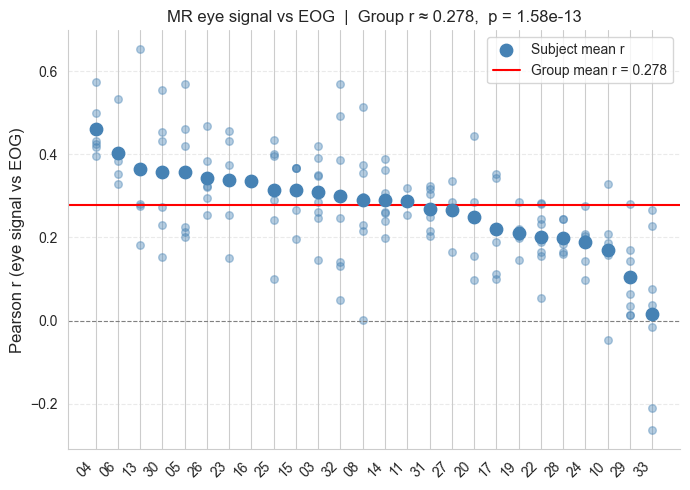

In [6]:

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Collect per-run correlations ──────────────────────────────────────────

records = []

for subject, run, run_df in dataset.iter_run_events():
    eye_signal, _ = dataset.load_eye_move(subject, run, desc_add="clean-with-fd-clamped")

    eog_rows = run_df["eog"]
    if eog_rows.isna().any():
        print(f"  Skipping {subject} run {run} (no EOG data)")
        continue

    eog_signal = eog_rows.values.astype(float)

    n = min(len(eye_signal), len(eog_signal))
    if len(eye_signal) != len(eog_signal):
        print(f"  Skipping {subject} run {run} (too few samples: {n})")
        continue

    r, p = stats.pearsonr(eye_signal, eog_signal)
    if r == np.nan:
        continue
    records.append(dict(
        subject=subject,
        run=run,
        r=r, p=p, n=n,
        mean_eye=np.mean(np.abs(eye_signal[:n])),
        mean_eog=np.mean(np.abs(eog_signal[:n])),
    ))

run_df = pd.DataFrame(records)
print(f"\nPer-run correlations ({len(run_df)} runs):")
# print(run_df.groupby("subject")["r"].agg(["mean", "std", "count"]).round(3))

# ── 2. Per-subject average r (Fisher z then back) ────────────────────────────

def fisher_mean(r_values):
    z = np.arctanh(np.clip(r_values, -0.9999, 0.9999))
    return np.tanh(np.mean(z))

subj_df = (
    run_df.groupby("subject")["r"]
    .agg(fisher_mean_r=lambda x: fisher_mean(x.values), n_runs="count")
    .reset_index()
)

print(f"\nPer-subject mean r (Fisher-averaged):")
print(subj_df.round(3))

# ── 3. Group-level summary ────────────────────────────────────────────────────

# Fisher z at the group level as well 
z_scores = np.arctanh(np.clip(subj_df["fisher_mean_r"].values, -0.9999, 0.9999))
group_r  = np.tanh(np.mean(z_scores))
se       = np.std(z_scores) / np.sqrt(len(z_scores))
ci_low   = np.tanh(np.mean(z_scores) - 1.96 * se)
ci_high  = np.tanh(np.mean(z_scores) + 1.96 * se)
t_stat, p_val = stats.ttest_1samp(z_scores, 0)

print(f"\nGroup-level MR-eye vs EOG correlation:")
print(f"  Mean r = {group_r:.3f}  95% CI [{ci_low:.3f}, {ci_high:.3f}]")
print(f"  One-sample t({len(z_scores)-1}) = {t_stat:.3f},  p = {p_val:.4f}")

# ── Plot: per-subject mean time-series r, with individual runs shown ──────────

subj_r = run_df.groupby("subject")["r"].agg(fisher_mean).reset_index()
subj_r.columns = ["subject", "mean_r"]
subj_r = subj_r.sort_values("mean_r", ascending=False).reset_index(drop=True)

p_str = f"{p_val:.2e}" if p_val < 0.001 else f"{p_val:.3f}"

fig, ax = plt.subplots(figsize=(7, 5))

# Individual run dots per subject
for i, row in subj_r.iterrows():
    runs = run_df[run_df["subject"] == row["subject"]]["r"].values
    ax.scatter([i] * len(runs), runs, color="steelblue", alpha=0.4, s=30, zorder=2)

# Subject mean
ax.scatter(range(len(subj_r)), subj_r["mean_r"], color="steelblue", s=80, zorder=3, label="Subject mean r")

# Reference lines
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.axhline(group_r, color="red", lw=1.5, ls="-", label=f"Group mean r = {group_r:.3f}")

ax.set_xticks(range(len(subj_r)))
ax.set_xticklabels(subj_r["subject"].str.replace("sub-", ""), rotation=45, ha="right")
ax.set_ylabel("Pearson r (eye signal vs EOG)", fontsize=12)
ax.set_title(f"MR eye signal vs EOG  |  Group r ≈ {group_r:.3f},  p = {p_str}", fontsize=12)
ax.legend()
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("/Users/zach/2025_RA/matthias/final images/correlations/mreyemove_eog_r_per_subject.png", dpi=300)
plt.show()

  Skipping 15 run 3 (no EOG data)
  Skipping 16 run 1 (no EOG data)
  Skipping 16 run 2 (no EOG data)
  Skipping 16 run 3 (no EOG data)
  Skipping 16 run 4 (no EOG data)
  Skipping 16 run 5 (no EOG data)
  Skipping 18 run 1 (no EOG data)
  Skipping 18 run 2 (no EOG data)
  Skipping 18 run 3 (no EOG data)
  Skipping 18 run 4 (no EOG data)
  Skipping 18 run 5 (no EOG data)

Per-run correlations (146 runs):

Per-subject mean r (Fisher-averaged):
   subject  fisher_mean_r  n_runs
0       03          0.075       8
1       04          0.030       6
2       05          0.017       6
3       06         -0.018       4
4       08         -0.016       7
5       10          0.027       6
6       11          0.034       2
7       13          0.022       4
8       14          0.034       7
9       15          0.057       5
10      16          0.137       1
11      17          0.060       6
12      19          0.043       5
13      20          0.119       4
14      22         -0.014       8
15      2

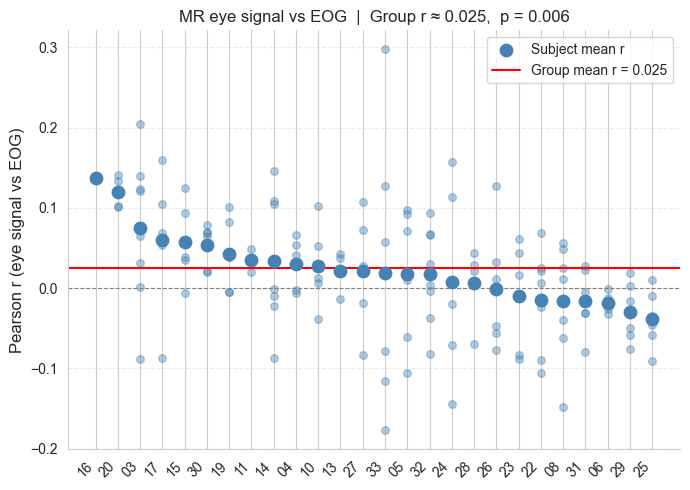

In [7]:
# CONTROL ANALYSIS - USE CSF

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Collect per-run correlations ──────────────────────────────────────────

records = []

for subject, run, run_df in dataset.iter_run_events():
    eye_signal = dataset.load_confounds(subject, run, confound_names=["csf"])["csf"].values

    eog_rows = run_df["eog"]
    if eog_rows.isna().any():
        print(f"  Skipping {subject} run {run} (no EOG data)")
        continue

    eog_signal = eog_rows.values.astype(float)

    n = min(len(eye_signal), len(eog_signal))
    if len(eye_signal) != len(eog_signal):
        print(f"  Skipping {subject} run {run} (too few samples: {n})")
        continue

    r, p = stats.pearsonr(eye_signal, eog_signal)
    if r == np.nan:
        continue
    records.append(dict(
        subject=subject,
        run=run,
        r=r, p=p, n=n,
        mean_eye=np.mean(np.abs(eye_signal[:n])),
        mean_eog=np.mean(np.abs(eog_signal[:n])),
    ))

run_df = pd.DataFrame(records)
print(f"\nPer-run correlations ({len(run_df)} runs):")
# print(run_df.groupby("subject")["r"].agg(["mean", "std", "count"]).round(3))

# ── 2. Per-subject average r (Fisher z then back) ────────────────────────────

def fisher_mean(r_values):
    z = np.arctanh(np.clip(r_values, -0.9999, 0.9999))
    return np.tanh(np.mean(z))

subj_df = (
    run_df.groupby("subject")["r"]
    .agg(fisher_mean_r=lambda x: fisher_mean(x.values), n_runs="count")
    .reset_index()
)

print(f"\nPer-subject mean r (Fisher-averaged):")
print(subj_df.round(3))

# ── 3. Group-level summary ────────────────────────────────────────────────────

# Fisher z at the group level as well 
z_scores = np.arctanh(np.clip(subj_df["fisher_mean_r"].values, -0.9999, 0.9999))
group_r  = np.tanh(np.mean(z_scores))
se       = np.std(z_scores) / np.sqrt(len(z_scores))
ci_low   = np.tanh(np.mean(z_scores) - 1.96 * se)
ci_high  = np.tanh(np.mean(z_scores) + 1.96 * se)
t_stat, p_val = stats.ttest_1samp(z_scores, 0)

print(f"\nGroup-level CSF vs EOG correlation:")
print(f"  Mean r = {group_r:.3f}  95% CI [{ci_low:.3f}, {ci_high:.3f}]")
print(f"  One-sample t({len(z_scores)-1}) = {t_stat:.3f},  p = {p_val:.4f}")

# ── Plot: per-subject mean time-series r, with individual runs shown ──────────

subj_r = run_df.groupby("subject")["r"].agg(fisher_mean).reset_index()
subj_r.columns = ["subject", "mean_r"]
subj_r = subj_r.sort_values("mean_r", ascending=False).reset_index(drop=True)

p_str = f"{p_val:.2e}" if p_val < 0.001 else f"{p_val:.3f}"

fig, ax = plt.subplots(figsize=(7, 5))

# Individual run dots per subject
for i, row in subj_r.iterrows():
    runs = run_df[run_df["subject"] == row["subject"]]["r"].values
    ax.scatter([i] * len(runs), runs, color="steelblue", alpha=0.4, s=30, zorder=2)

# Subject mean
ax.scatter(range(len(subj_r)), subj_r["mean_r"], color="steelblue", s=80, zorder=3, label="Subject mean r")

# Reference lines
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.axhline(group_r, color="red", lw=1.5, ls="-", label=f"Group mean r = {group_r:.3f}")

ax.set_xticks(range(len(subj_r)))
ax.set_xticklabels(subj_r["subject"].str.replace("sub-", ""), rotation=45, ha="right")
ax.set_ylabel("Pearson r (eye signal vs EOG)", fontsize=12)
ax.set_title(f"MR eye signal vs EOG  |  Group r ≈ {group_r:.3f},  p = {p_str}", fontsize=12)
ax.legend()
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("/Users/zach/2025_RA/matthias/final images/correlations/csf_eog_r_per_subject.png", dpi=300)
plt.show()

In [4]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# ── Parameters ────────────────────────────────────────────────────────────────

STATES   = ["W", "S"]
N_PERMS  = 5000
TRIM     = 1
MIN_BLOCK = 5   # minimum TRs in a block after trimming

# ── Helper: extract contiguous paired (eye, EOG) blocks ───────────────────────

def extract_paired_blocks(eye, eog, mask, trim=TRIM, min_len=MIN_BLOCK):
    """
    Returns list of (eye_arr, eog_arr) for every contiguous True run in `mask`,
    with `trim` TRs removed from each edge.
    """
    blocks = []
    n, i = len(mask), 0
    while i < n:
        if mask[i]:
            j = i
            while j < n and mask[j]:
                j += 1
            s, e = i + trim, j - trim
            if e - s >= min_len:
                blocks.append((eye[s:e], eog[s:e]))
            i = j
        else:
            i += 1
    return blocks

def fisher_mean(r_values):
    z = np.arctanh(np.clip(np.asarray(r_values), -0.9999, 0.9999))
    return np.tanh(np.mean(z))

def subject_mean_r(blocks):
    """Fisher-average Pearson r across all blocks for one subject."""
    rs = [stats.pearsonr(eye, eog)[0] for eye, eog in blocks if len(eye) >= MIN_BLOCK]
    return np.mean(rs) if rs else np.nan

# ── 1. Collect paired (eye, EOG) blocks per subject × state ──────────────────

state_subject_blocks = {s: {} for s in STATES}

for subject in dataset.subjects:
    run_blocks = {s: [] for s in STATES}
    valid = False

    for _, run, run_df in dataset.iter_run_events(subject=subject):
        eye_signal, _ = dataset.load_eye_move(subject, run, desc_add="clean-with-fd-clamped")

        eog_col = run_df["eog"]
        if eog_col.isna().any():
            print(f"  Skipping {subject} run {run} (no EOG)")
            continue

        eog_signal = eog_col.values.astype(float)
        n = min(len(eye_signal), len(eog_signal))
        eye_signal, eog_signal = eye_signal[:n], eog_signal[:n]

        for state in STATES:
            mask = run_df[state].values[:n].astype(bool)
            for pair in extract_paired_blocks(eye_signal, eog_signal, mask):
                run_blocks[state].append(pair)
                valid = True

    if not valid:
        continue
    for state in STATES:
        if run_blocks[state]:
            state_subject_blocks[state][subject] = run_blocks[state]

# ── 2. Observed group-mean r per state ────────────────────────────────────────

state_results = {}

for state in STATES:
    subj_blocks = state_subject_blocks[state]
    subjects    = [s for s, bl in subj_blocks.items() if subject_mean_r(bl) is not np.nan]
    obs_r_subj  = np.array([subject_mean_r(subj_blocks[s]) for s in subjects])
    obs_r_subj  = obs_r_subj[~np.isnan(obs_r_subj)]

    obs_z       = np.arctanh(np.clip(obs_r_subj, -0.9999, 0.9999))
    group_r     = np.tanh(np.mean(obs_z))
    group_z     = np.mean(obs_z)

    state_results[state] = dict(
        subjects=subjects,
        obs_r_subj=obs_r_subj,
        group_r=group_r,
        group_z=group_z,
    )

# ── 3. Permutation test (shuffle EOG within each block) ───────────────────────

rng = np.random.default_rng(42)

for state in STATES:
    res         = state_results[state]
    subjects    = res["subjects"]
    subj_blocks = state_subject_blocks[state]
    obs_z       = res["group_z"]

    null_dist = np.empty(N_PERMS)

    for perm_i in range(N_PERMS):
        perm_subj_z = []
        for s in subjects:
            perm_rs = []
            for eye_block, eog_block in subj_blocks[s]:
                eog_perm = rng.permutation(eog_block)   # shuffle EOG within block
                r, _ = stats.pearsonr(eye_block, eog_perm)
                if not np.isnan(r):
                    perm_rs.append(r)
            if perm_rs:
                perm_subj_z.append(np.arctanh(np.clip(fisher_mean(perm_rs), -0.9999, 0.9999)))
        null_dist[perm_i] = np.mean(perm_subj_z) if perm_subj_z else 0.0

    p_perm = np.mean(null_dist >= obs_z)   # one-tailed (r > 0)

    # 95 % CI from bootstrap (consistent with permutation approach)
    boot = np.array([
        np.mean(rng.choice(res["obs_r_subj"], size=len(res["obs_r_subj"]), replace=True))
        for _ in range(N_PERMS)
    ])
    ci_low, ci_high = np.percentile(boot, [2.5, 97.5])

    res.update(null_dist=null_dist, p_perm=p_perm, ci_low=ci_low, ci_high=ci_high)

    n_subj = len(subjects)
    print(f"\nState {state}  ({n_subj} subjects)")
    print(f"  Group r = {res['group_r']:.3f}  95% CI [{ci_low:.3f}, {ci_high:.3f}]")
    print(f"  Permutation p (one-tailed) = {p_perm:.4f}  (N={N_PERMS})")

# ── 4. Plot ────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
state_colors = {"W": "steelblue", "S": "mediumpurple"}

for ax, state in zip(axes, STATES):
    res     = state_results[state]
    color   = state_colors[state]
    subjects = res["subjects"]
    subj_blocks = state_subject_blocks[state]
    obs_r_subj = res["obs_r_subj"]
    group_r    = res["group_r"]
    p_perm     = res["p_perm"]
    ci_low, ci_high = res["ci_low"], res["ci_high"]

    # Sort subjects by mean r
    order = np.argsort(obs_r_subj)[::-1]
    sorted_subjs = [subjects[i] for i in order]
    sorted_r     = obs_r_subj[order]

    # Individual run dots
    for xi, s in enumerate(sorted_subjs):
        run_rs = [stats.pearsonr(eye, eog)[0] for eye, eog in subj_blocks[s]]
        ax.scatter([xi] * len(run_rs), run_rs,
                   color=color, alpha=0.3, s=25, zorder=2)

    # Subject means
    ax.scatter(range(len(sorted_subjs)), sorted_r,
               color=color, s=80, zorder=3, label="Subject mean r")

    # Group mean ± CI band
    ax.axhline(group_r, color="red", lw=1.8, label=f"Group r = {group_r:.3f}")
    ax.axhspan(ci_low, ci_high, color="red", alpha=0.12, label="95% CI")
    ax.axhline(0, color="gray", lw=0.8, ls="--")

    p_str = f"{p_perm:.2e}" if p_perm < 0.001 else f"{p_perm:.3f}"
    ax.set_title(f"State: {state}  |  r={group_r:.3f}, p={p_str} (perm)", fontsize=11)
    ax.set_xticks(range(len(sorted_subjs)))
    ax.set_xticklabels(
        [s.replace("sub-", "") for s in sorted_subjs],
        rotation=45, ha="right", fontsize=8
    )
    ax.set_ylabel("Pearson r  (eye signal vs EOG)" if state == STATES[0] else "")
    ax.legend(fontsize=9)
    ax.grid(True, axis="y", ls="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

    # Inset: null distribution
    ax_in = ax.inset_axes([0.65, 0.05, 0.32, 0.30])
    ax_in.hist(res["null_dist"], bins=60, color=color, alpha=0.6, density=True)
    ax_in.axvline(res["group_z"], color="red", lw=1.5)
    ax_in.set_title("Null dist (z)", fontsize=7)
    ax_in.set_xlabel("Mean Fisher-z", fontsize=6)
    ax_in.tick_params(labelsize=6)
    ax_in.spines[["top", "right"]].set_visible(False)

fig.suptitle("MR eye signal vs EOG: per-state permutation test", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("mreyemove_eog_r_by_state_perm.svg", dpi=150, bbox_inches="tight")
plt.show()

  Skipping 18 run 1 (no EOG)
  Skipping 18 run 2 (no EOG)
  Skipping 18 run 3 (no EOG)
  Skipping 18 run 4 (no EOG)
  Skipping 18 run 5 (no EOG)
  Skipping 16 run 1 (no EOG)
  Skipping 16 run 2 (no EOG)
  Skipping 16 run 3 (no EOG)
  Skipping 16 run 4 (no EOG)
  Skipping 16 run 5 (no EOG)
  Skipping 15 run 3 (no EOG)


KeyboardInterrupt: 